# Estimating Non-Penalty Shot-Scoring Probability in the FA Women's Super League
### A from-scratch logistic regression study of geometry vs. shot context

**31005 Machine Learning — Assessment Task 2 (Project Journal: implementation notebook)**

| | |
|---|---|
| Author | *[Name, Student ID, Year]* |
| Research question | Does adding shot-context information, known at the moment of ball strike, to a geometry-only logistic model improve out-of-season probabilistic prediction of non-penalty goals? |
| Population | Non-penalty shots, FA Women's Super League (StatsBomb Open Data) |
| Main comparison | M1\* (geometry) vs. M2\* (geometry + shot context), same algorithm, same geometric mapping |
| Primary metric | Test-season log loss difference, match-level paired bootstrap 95% CI |
| Final test | 2023/24 season, evaluated by this notebook once, after the full protocol is frozen (see disclosure in §1.4) |

**AI use.** [AI involvement — brief note: e.g. code drafting, implementation review and verification of the pipeline; to be edited by the author. Full record: Journal → Implementation Log → AI tool use.]

**Data.** Data provided by StatsBomb (StatsBomb Open Data, https://github.com/statsbomb/open-data), pinned to a fixed repository commit (Section 1). Use follows the StatsBomb open-data user agreement and attribution requirements.

**How to run.** `Runtime → Run all` in a fresh Google Colab session. The notebook installs nothing beyond the Colab defaults, downloads the required event files from the pinned commit, and caches them locally. Expected runtime: about 3–6 minutes, dominated by the one-off download (~0.95 GB for the three development seasons).

**Version.** The code presented in the A3 demo is the archived version at the GitHub commit linked in the Journal. The test season is downloaded only in Section 10, after the frozen record is created in Section 9.


## 0. Navigation

| Notebook section | Journal section | Main rubric evidence |
|---|---|---|
| 1 Locked task definition, configuration and protocol | Problem Definition, Data | A |
| 2 Data acquisition and metadata | Data | A |
| 3 Data audit (development seasons) | Data | A, C |
| 4 Shot table, features, leakage checks | Data, ML Approach | A, B |
| 5 From-scratch logistic regression (H–L–A) | ML Approach | B |
| 6 Implementation correctness | ML Approach (verification) | B |
| 7 Evaluation tools and their validation | ML Approach (evaluation) | C |
| 8 Development: training pool, φ\*, λ | ML Approach, Results | B, C |
| 9 Frozen record and refit | ML Approach | C |
| 10 Final test (2023/24, once) | Results | C |
| 11 Deployment I/O demo | Problem Definition | A |
| 12 Conclusion | Discussion | A, C |


**Theory-to-code index**

| Concept | Where |
|---|---|
| Distance, shot angle (atan2, two posts) | §4.2 `shot_distance`, `shot_angle` |
| Hypothesis $h_\theta(x)=\sigma(\theta^\top x)$ | §5.2 `LogisticRegressionScratch.predict_proba` |
| Numerically stable sigmoid | §5.1 `sigmoid` |
| Loss: mean binary cross-entropy + L2 (intercept not penalised) | §5.1 `objective` |
| Gradient $\frac1N X^\top(p-y)+\lambda\tilde\theta$ | §5.1 `gradient` |
| Optimiser: gradient descent with step $1/L$, Nesterov momentum | §5.2 `LogisticRegressionScratch.fit` |
| Preprocessing fitted on training data only | §5.3 `Preprocessor` |
| sklearn equivalence $C=1/(\lambda N)$ | §6 check 5 |
| Log loss, Brier, AUC, calibration-in-the-large, calibration slope | §7.1 |
| Match-level paired bootstrap | §7.2 `paired_bootstrap` |

## 1. Locked task definition, configuration and protocol

### 1.1 Task
* **Training input:** one row per non-penalty shot from the training seasons, containing only information fixed at the moment of ball strike; **training label:** $y\in\{0,1\}$, 1 if the shot resulted in a goal; **training output:** fitted parameters $\hat\theta$ of a logistic model.
* **Deployment input:** one structured post-match event record of a new non-penalty shot (location and strike-time context); **deployment output:** $\hat p = P(Y=1\mid X=x)\in(0,1)$ — a probability, not a goal/no-goal decision.
* **Information cut-off:** the moment of ball strike. Anything produced after the ball leaves the player (outcome, end location, deflection, goalkeeper action, StatsBomb's own xG) is excluded.
* **Out of scope:** real-time use, player evaluation, shooting-decision advice, causal claims, penalties.

### 1.2 Data roles
| Season | StatsBomb season_id | Role |
|---|---|---|
| 2018/19 | 4 | Candidate training data (part of $D_{full}$) |
| 2019/20 | 42 | Training data (in both $D_{full}$ and $D_{recent}$) |
| 2020/21 | 90 | Validation: exactly two structural choices (training pool, φ\*); merged into the final refit afterwards, never used to re-open a decision |
| 2023/24 | 281 | Final test: events accessed by this corrected notebook only after freezing; the frozen pipeline is evaluated once (an earlier invalid evaluation by a separate implementation is disclosed in §1.4) |

### 1.3 Decision order (pre-registered)
1. **Training pool.** Untransformed M2 on $D_{full}$ vs $D_{recent}$ (λ chosen by match-grouped CV inside each pool); paired match bootstrap on 2020/21; exclude 2018/19 only if $\Delta_{legacy}=LL_{full}-LL_{recent}>0$ with the whole 95% CI above 0.
2. **Common geometric mapping φ\*.** For each pre-listed candidate, M1 is tuned by match-grouped CV inside the chosen pool, then compared on 2020/21; the lowest validation log loss wins (ties within $10^{-4}$ go to the simpler, earlier-listed candidate). The same φ\* is used by M1\* and M2\*.
3. **Final λ.** M1\* keeps the λ selected by CV for the chosen candidate; M2\* selects its own λ with the same CV protocol inside the chosen pool.
4. **Freeze, refit on pool + 2020/21, test once on 2023/24.**

All thresholds, grids and definitions are in `CONFIG` below and are not changed after validation or test results are seen.

### 1.4 Integrity disclosure and revision log
* **Earlier test use.** The 2023/24 season was evaluated once by an earlier, separate implementation of this project, whose outputs were viewed during development [AI involvement — brief note: the earlier implementation was generated and executed with an AI coding tool, which viewed its test outputs; to be edited by the author]. That implementation used the post-strike field `deflected` as a model input, violating the declared information cut-off. Its results are invalid and are not reported. The test season can therefore not be described as never used; no design choice in this notebook was based on those results.
* **Revision R1 (made before this notebook accessed any test data).** The first development run of this notebook showed near-separated coefficients for tiny categories (e.g. a key-pass category with 39 shots and 0 goals; a rare-category bucket consisting of 2 direct corner shots, both goals), which would give such shots probabilities near 0 or 1 at deployment. The rare-category rule was therefore replaced by a supervised, fold-fitted category-support rule requiring ≥30 shots, ≥5 goals and ≥5 non-goals, with the same rule applied to the bucket. The rule was introduced after the first development run (it is not a pre-registered rule); its thresholds were fixed in R1 and not tuned further. The motivation was coefficient diagnostics on training data, not validation or test performance. All development decisions were then re-run from scratch.

In [1]:
import hashlib, json, os, time, math, warnings
import concurrent.futures as cf
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

CONFIG = {
    # --- data source (pinned) ---
    "statsbomb_repo": "statsbomb/open-data",
    "statsbomb_commit": "4b73468fc5b0f1950f9f66fada70ad3a4f9327cb",
    "competition_id": 37,  # FA Women's Super League
    "seasons": {"2018/19": 4, "2019/20": 42, "2020/21": 90, "2023/24": 281},
    "development_seasons": [4, 42, 90],
    "validation_season": 90,
    "test_season": 281,
    "pools": {"D_full": [4, 42], "D_recent": [42]},

    # --- pitch geometry (StatsBomb 120 x 80 coordinates, attacking left -> right) ---
    "goal_x": 120.0, "goal_centre_y": 40.0, "goal_width": 8.0,  # posts at y = 36 and y = 44
    "penalty_box": {"x_min": 102.0, "y_min": 18.0, "y_max": 62.0},
    "valid_x": [0.0, 120.0], "valid_y": [0.0, 80.0],

    # --- population ---
    "exclude_shot_types": ["Penalty"],

    # --- features (strike-time information only) ---
    "context_categorical": ["body_part", "shot_type", "technique", "play_pattern", "assist_type"],
    "context_boolean": ["first_time", "under_pressure", "one_on_one", "open_goal", "aerial_won"],
    # Revision R1 (see §1.4): a category keeps its own coefficient only if it has enough shots AND enough
    # goals AND enough non-goals in the fitting data; the RARE_OR_UNSEEN bucket obeys the same rule,
    # otherwise it is merged into the reference level.
    "rare_rule": {"min_shots": 30, "min_goals": 5, "min_non_goals": 5},
    "rare_bucket": "RARE_OR_UNSEEN",
    "excluded_by_estimand": ["minute", "score_state", "home_away", "team", "player"],
    "leakage_fields": ["outcome", "is_goal", "end_location", "statsbomb_xg", "deflected", "redirect",
                       "saved_off_target", "saved_to_post", "out", "freeze_frame", "match_id", "shot_id"],

    # --- geometric mapping candidates (phi), in order of simplicity ---
    "phi_candidates": ["raw", "log_distance", "distance_quadratic", "log_distance_x_angle"],
    "phi_tie_tolerance": 1e-4,

    # --- model fitting ---
    "lambda_grid": [1e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],   # mean-loss parameterisation
    "cv_folds": 5,
    "lambda_rule": "minimum pooled out-of-fold log loss; ties within lambda_tie_tolerance -> larger lambda",
    "lambda_tie_tolerance": 1e-4,
    "optimizer": {"method": "nesterov", "grad_tol": 1e-6, "max_iter": 20000},

    # --- evaluation ---
    "bootstrap": {"B": 2000, "unit": "match", "ci": 0.95},
    "pool_rule": "exclude 2018/19 iff LL_full - LL_recent > 0 and 95% CI lower bound > 0",
    "prob_eps": 1e-6,                     # probability clipping inside metric computations (numerical safety)
    "calibration_bins": 10,               # equal-frequency bins
    "subgroups": {"header": "body_part == 'Head'", "inside_box": "inside_box == 1"},
    "high_prob_group": "top 10% of M2* test predictions (label-free definition)",
    "min_goals_for_inference": 20,        # smaller subgroups are described, not tested
    "classification_threshold": 0.5,      # only for the class-weighting illustration (recall/precision)
    "known_outcomes": ["Blocked", "Goal", "Off T", "Post", "Saved", "Saved Off Target", "Saved to Post", "Wayward"],
    "class_weight": {"rule": "balanced: w_c = N / (2 N_c), mean weight = 1",
                     "fitted_on": "final fitting data", "other_settings": "identical to M2*"},
    "test_failure_rules": {
        "unseen_category": "map to RARE_OR_UNSEEN of that feature (reference level if the bucket is inactive); report count",
        "no_key_pass_id": "assist_type = 'No recorded key pass'",
        "key_pass_link_missing": "assist_type = 'Key pass link missing'; report count",
        "absent_true_only_boolean": "False (documented true-only flags)",
        "missing_or_invalid_location": "shot not evaluable; excluded from all metrics; report count",
        "dataset_level_failure": "stop the test computation; do not modify the frozen pipeline",
    },
    "seed": 31005,
}

def config_fingerprint(cfg):
    """Short hash of the canonical JSON form of a configuration dictionary."""
    blob = json.dumps(cfg, sort_keys=True, default=str).encode()
    return hashlib.sha256(blob).hexdigest()[:12]

RNG = np.random.default_rng(CONFIG["seed"])
FROZEN = False            # becomes True only in Section 9 after the frozen record is written

print("Pre-registration fingerprint:", config_fingerprint(CONFIG))
print("numpy", np.__version__, "| pandas", pd.__version__)

Pre-registration fingerprint: b10eee3a8cb9
numpy 2.4.4 | pandas 3.0.2


## 2. Data acquisition and match metadata

Only the three development seasons' event files are downloaded here. For the test season only the match IDs and version metadata are kept: the match file also contains final scores, which are outcome information, so those columns are dropped immediately and never displayed.

In [2]:
RAW_BASE = f"https://raw.githubusercontent.com/{CONFIG['statsbomb_repo']}/{CONFIG['statsbomb_commit']}/data"
CACHE_DIR = Path(os.environ.get("SB_CACHE", "/content/sb_cache" if Path("/content").exists() else "./sb_cache"))
(CACHE_DIR / "events").mkdir(parents=True, exist_ok=True)

def fetch_bytes(url, retries=3, timeout=90):
    last = None
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(url, timeout=timeout) as r:
                return r.read()
        except Exception as e:           # network errors are reported clearly, not hidden
            last = e
            time.sleep(1 + attempt)
    raise RuntimeError(f"Download failed after {retries} attempts: {url}\n{last}")

def load_matches(season_id):
    path = CACHE_DIR / f"matches_{CONFIG['competition_id']}_{season_id}.json"
    if not path.exists():
        path.write_bytes(fetch_bytes(f"{RAW_BASE}/matches/{CONFIG['competition_id']}/{season_id}.json"))
    rows = []
    for m in json.loads(path.read_bytes()):
        md = m.get("metadata", {}) or {}
        rows.append({
            "match_id": m["match_id"], "season_id": season_id, "match_date": m["match_date"],
            "home_team_id": m["home_team"]["home_team_id"], "away_team_id": m["away_team"]["away_team_id"],
            "data_version": md.get("data_version"), "shot_fidelity_version": md.get("shot_fidelity_version"),
            "xy_fidelity_version": md.get("xy_fidelity_version"),
        })                                                    # scores deliberately not kept
    return pd.DataFrame(rows)

matches = pd.concat([load_matches(s) for s in CONFIG["seasons"].values()], ignore_index=True)
season_name = {v: k for k, v in CONFIG["seasons"].items()}
matches["season"] = matches["season_id"].map(season_name)
matches["version_group"] = (matches["data_version"].fillna("?") + " | shot_fid=" +
                            matches["shot_fidelity_version"].fillna("none") + " | xy_fid=" +
                            matches["xy_fidelity_version"].fillna("none"))

expected = {"2018/19": 110, "2019/20": "curtailed (COVID-19)", "2020/21": 132, "2023/24": 132}
summary = (matches.groupby(["season", "version_group"]).size().rename("matches").reset_index())
display(summary)
display(pd.DataFrame({"season": list(expected), "full-season fixtures": list(expected.values()),
                      "available": [int((matches.season == s).sum()) for s in expected]}))

,season,version_group,matches
0,2018/19,1.0.3 | shot_fid=none | xy_fid=none,80
1,2018/19,1.1.0 | shot_fid=2 | xy_fid=none,20
2,2018/19,1.1.0 | shot_fid=none | xy_fid=none,7
3,2019/20,1.1.0 | shot_fid=2 | xy_fid=2,87
4,2020/21,1.1.0 | shot_fid=2 | xy_fid=2,131
5,2023/24,1.1.0 | shot_fid=2 | xy_fid=2,132


,season,full-season fixtures,available
0,2018/19,110,107
1,2019/20,curtailed (COVID-19),87
2,2020/21,132,131
3,2023/24,132,132


In [3]:
def download_events(match_ids, workers=16):
    """Download event files for the given matches (cached). Returns a manifest of file hashes."""
    def one(mid):
        p = CACHE_DIR / "events" / f"{mid}.json"
        if not p.exists():
            p.write_bytes(fetch_bytes(f"{RAW_BASE}/events/{mid}.json"))
        b = p.read_bytes()
        return mid, len(b), hashlib.sha256(b).hexdigest()
    with cf.ThreadPoolExecutor(workers) as ex:
        out = list(ex.map(one, match_ids))
    return pd.DataFrame(out, columns=["match_id", "bytes", "sha256"]).sort_values("match_id")

def data_digest(manifest):
    lines = "\n".join(f"{m}:{h}" for m, h in zip(manifest.match_id, manifest.sha256))
    return hashlib.sha256(lines.encode()).hexdigest()[:12]

t0 = time.time()
dev_ids = matches.loc[matches.season_id.isin(CONFIG["development_seasons"]), "match_id"].tolist()
dev_manifest = download_events(dev_ids)
print(f"Development event files: {len(dev_manifest)} matches, "
      f"{dev_manifest.bytes.sum()/1e6:.0f} MB, {time.time()-t0:.0f}s")
print("Development data digest:", data_digest(dev_manifest))

Development event files: 325 matches, 945 MB, 1s
Development data digest: 7a26a9d3f8c5


### 2.1 Shot extraction

One row = one shot. Extraction returns three separate objects so that leakage is prevented at source:
* `X_raw` — strike-time information only (location, body part, shot type, technique, play pattern, flags, key-pass type);
* `y` — the goal label;
* `ref` — StatsBomb's own xG, kept only as an external reference for the final test.

Post-strike fields (end location, outcome, deflection, `out`, saved flags) are never copied into `X_raw`.

**Boolean flags.** StatsBomb records `first_time`, `under_pressure`, `one_on_one`, `open_goal` and `aerial_won` only when true; absence is mapped to `False`. **Key pass.** No `key_pass_id` → `"No recorded key pass"`; an id that cannot be found in the match's events → `"Key pass link missing"` (a data-quality category, reported separately).

In [4]:
def key_pass_type(kp):
    """Categorise the key pass that set up the shot (priority order is fixed)."""
    p = kp.get("pass", {})
    technique = (p.get("technique") or {}).get("name")
    pass_type = (p.get("type") or {}).get("name")
    if p.get("cross"):
        return "Cross"
    if p.get("through_ball") or technique == "Through Ball":   # both representations occur across data versions
        return "Through ball"
    if p.get("cut_back"):
        return "Cut back"
    if pass_type in ("Corner", "Free Kick", "Throw-in"):
        return "Set-piece pass"
    return (p.get("height") or {}).get("name", "Unknown height")   # Ground / Low / High Pass

def extract_shots(match_row):
    events = json.loads((CACHE_DIR / "events" / f"{match_row.match_id}.json").read_bytes())
    by_id = {e["id"]: e for e in events}
    X_rows, y_rows, ref_rows = [], [], []
    for e in events:
        if e["type"]["name"] != "Shot":
            continue
        s = e["shot"]
        loc = e.get("location") or [None, None]
        kp_id = s.get("key_pass_id")
        if kp_id is None:
            assist = "No recorded key pass"
        elif kp_id not in by_id:
            assist = "Key pass link missing"
        else:
            assist = key_pass_type(by_id[kp_id])
        X_rows.append({
            "shot_id": e["id"], "match_id": match_row.match_id, "season_id": match_row.season_id,
            "team_id": e["team"]["id"], "version_group": match_row.version_group,
            "x": loc[0], "y": loc[1],
            "body_part_raw": s["body_part"]["name"], "shot_type": s["type"]["name"],
            "technique": s["technique"]["name"], "play_pattern": e["play_pattern"]["name"],
            "assist_type": assist,
            "first_time": bool(s.get("first_time", False)), "under_pressure": bool(e.get("under_pressure", False)),
            "one_on_one": bool(s.get("one_on_one", False)), "open_goal": bool(s.get("open_goal", False)),
            "aerial_won": bool(s.get("aerial_won", False)),
        })
        y_rows.append({"shot_id": e["id"], "is_goal": int(s["outcome"]["name"] == "Goal"),
                       "outcome_name": s["outcome"]["name"]})
        ref_rows.append({"shot_id": e["id"], "statsbomb_xg": s.get("statsbomb_xg")})
    return X_rows, y_rows, ref_rows

def build_tables(match_rows):
    X, Y, R = [], [], []
    for row in match_rows.itertuples(index=False):
        a, b, c = extract_shots(row)
        X += a; Y += b; R += c
    X, Y, R = pd.DataFrame(X), pd.DataFrame(Y), pd.DataFrame(R)
    if not X.shot_id.is_unique:
        raise RuntimeError("Dataset-level failure: duplicate shot ids")
    Y = Y.set_index("shot_id")
    return X.set_index("shot_id"), Y["is_goal"], R.set_index("shot_id")["statsbomb_xg"], Y["outcome_name"]

def build_dev_tables():
    rows = matches[matches.season_id.isin(CONFIG["development_seasons"])]
    return build_tables(rows)

# The test-season loader (`build_test_tables`) is defined in Section 10 and refuses to run
# unless the protocol has been frozen in Section 9.

X_dev_raw, y_dev_raw, ref_dev_raw, outcome_dev_raw = build_dev_tables()
unknown_dev = set(outcome_dev_raw.unique()) - set(CONFIG["known_outcomes"])
assert not unknown_dev, f"Unrecognised outcome codes: {unknown_dev}"
print("Development shots extracted:", len(X_dev_raw))

Development shots extracted: 8287


## 3. Data audit (development seasons only)

The purpose is to check whether measurement and recording practice differ between data versions, because the training-pool decision (Step 1) concerns exactly this. The test season is audited only through its match metadata (Section 2); its events are not opened here.

In [5]:
aud = X_dev_raw.join(y_dev_raw)
aud["season"] = aud.season_id.map(season_name)
aud["integer_coords"] = (np.mod(aud.x, 1) == 0) & (np.mod(aud.y, 1) == 0)
aud["has_key_pass"] = aud.assist_type != "No recorded key pass"
audit = (aud.groupby(["season", "version_group"])
           .agg(shots=("x", "size"), integer_coords=("integer_coords", "mean"),
                first_time=("first_time", "mean"), under_pressure=("under_pressure", "mean"),
                aerial_won=("aerial_won", "mean"), one_on_one=("one_on_one", "mean"),
                has_key_pass=("has_key_pass", "mean"), goal_rate=("is_goal", "mean"))
           .round(3))
display(audit)
print("Key pass links missing:", int((aud.assist_type == "Key pass link missing").sum()))

shots  integer_coords  first_time  under_pressure  aerial_won  one_on_one  has_key_pass  goal_rate
season  version_group                                                                                                                          
2018/19 1.0.3 | shot_fid=none | xy_fid=none   2158           1.000       0.121           0.137       0.056       0.052         0.689      0.106
        1.1.0 | shot_fid=2 | xy_fid=none       504           0.010       0.300           0.208       0.105       0.056         0.675      0.113
        1.1.0 | shot_fid=none | xy_fid=none    154           1.000       0.221           0.169       0.084       0.065         0.675      0.162
2019/20 1.1.0 | shot_fid=2 | xy_fid=2         2223           0.013       0.310           0.207       0.057       0.049         0.673      0.113
2020/21 1.1.0 | shot_fid=2 | xy_fid=2         3248           0.014       0.342           0.221       0.091       0.044         0.682      0.122

Key pass links missing: 0


**Reading the audit.** Rates are shares of shots in each season × data-version group. Differences in flag rates between versions are *consistent with* changes in recording practice as well as genuine football differences; the audit cannot separate the two. This is why the training-pool decision is made empirically (Step 1) and interpreted as the net effect of including the older season, not as proof that data fidelity alone matters.

## 4. Shot table, features and leakage checks
### 4.1 Sample flow

In [6]:
def apply_population(X, y):
    """Population rules shared by development and test data."""
    flow = [("All shots", len(X))]
    keep = ~X.shot_type.isin(CONFIG["exclude_shot_types"])
    flow.append(("After excluding penalties", int(keep.sum())))
    vx, vy = CONFIG["valid_x"], CONFIG["valid_y"]
    loc_ok = (X.x.notna() & X.y.notna() & X.x.between(*vx) & X.y.between(*vy))
    keep &= loc_ok
    flow.append(("After excluding missing/invalid locations", int(keep.sum())))
    return X[keep].copy(), y[keep].copy(), pd.DataFrame(flow, columns=["step", "shots"])

X_dev, y_dev, flow_dev = apply_population(X_dev_raw, y_dev_raw)
ref_dev = ref_dev_raw.loc[X_dev.index]
flow_by_season = pd.concat(
    [apply_population(X_dev_raw[X_dev_raw.season_id == s], y_dev_raw[X_dev_raw.season_id == s])[2]
       .set_index("step").rename(columns={"shots": season_name[s]}) for s in CONFIG["development_seasons"]],
    axis=1)
display(flow_by_season)

,2018/19,2019/20,2020/21
step,,,
All shots,2816,2223,3248
After excluding penalties,2792,2201,3212
After excluding missing/invalid locations,2792,2201,3211


### 4.2 Geometric features

With $d = 120 - x$ (distance to the goal line) and $u = 40 - y$ (lateral offset from the goal centre), the vectors to the posts at $y=36$ and $y=44$ are $v_1=(d,\,u-4)$ and $v_2=(d,\,u+4)$. The angle subtended by the goal mouth is

$$\theta=\operatorname{atan2}\big(|\det(v_1,v_2)|,\; v_1\cdot v_2\big)=\operatorname{atan2}\big(8|d|,\; d^2+u^2-16\big).$$

`atan2` is required: when the shot is very close to the goal line between the posts, $v_1\cdot v_2<0$ and the angle exceeds $90^\circ$, which `arctan` of the ratio would return in the wrong quadrant.

In [7]:
def shot_distance(x, y):
    return np.hypot(CONFIG["goal_x"] - np.asarray(x, float), CONFIG["goal_centre_y"] - np.asarray(y, float))

def shot_angle(x, y):
    d = CONFIG["goal_x"] - np.asarray(x, float)
    u = CONFIG["goal_centre_y"] - np.asarray(y, float)
    half = CONFIG["goal_width"] / 2
    return np.arctan2(CONFIG["goal_width"] * np.abs(d), d**2 + u**2 - half**2)

def inside_box(x, y):
    b = CONFIG["penalty_box"]
    return ((np.asarray(x) >= b["x_min"]) & (np.asarray(y) >= b["y_min"]) & (np.asarray(y) <= b["y_max"])).astype(int)

# --- unit tests for the geometry (expected values derived by hand) ---
geo_tests = [
    ("penalty spot angle = 2·atan(4/12)", shot_angle(108, 40), 2 * np.arctan(4 / 12)),
    ("left/right symmetry", shot_angle(110, 30), shot_angle(110, 50)),
    ("on goal line between posts = 180°", shot_angle(120, 40), np.pi),
    ("on goal line outside posts = 0°", shot_angle(120, 30), 0.0),
    ("distance from penalty spot = 12", shot_distance(108, 40), 12.0),
    ("angle > 90° close to goal (atan2 quadrant)", float(shot_angle(119.5, 40) > np.pi / 2), 1.0),
]
geo_df = pd.DataFrame([(n, float(a), float(b), bool(np.isclose(a, b, atol=1e-9))) for n, a, b in geo_tests],
                      columns=["test", "computed", "expected", "pass"])
xs = np.linspace(60, 118, 50)
geo_df.loc[len(geo_df)] = ["angle decreases along centre line", np.nan, np.nan,
                           bool(np.all(np.diff(shot_angle(xs, 40 * np.ones_like(xs))) > 0))]
display(geo_df)
assert geo_df["pass"].all(), "Geometry unit test failed"

,test,computed,expected,pass
0,penalty spot angle = 2·atan(4/12),0.643501,0.643501,True
1,left/right symmetry,0.410127,0.410127,True
2,on goal line between posts = 180°,3.141593,3.141593,True
3,on goal line outside posts = 0°,0.000000,0.000000,True
4,distance from penalty spot = 12,12.000000,12.000000,True
5,angle > 90° close to goal (atan2 quadrant),1.000000,1.000000,True
6,angle decreases along centre line,NaN,NaN,True


### 4.3 Context features and the feature table

In [8]:
def build_features(X):
    F = pd.DataFrame(index=X.index)
    F["distance"] = shot_distance(X.x, X.y)
    F["angle"] = shot_angle(X.x, X.y)
    F["inside_box"] = inside_box(X.x, X.y)                      # used for subgroup definition only
    F["body_part"] = X.body_part_raw.replace({"Right Foot": "Foot", "Left Foot": "Foot"})
    for c in ["shot_type", "technique", "play_pattern", "assist_type"]:
        F[c] = X[c]
    for c in CONFIG["context_boolean"]:
        F[c] = X[c].astype(int)
    return F

F_dev = build_features(X_dev)
meta_dev = X_dev[["match_id", "season_id", "team_id", "version_group"]]

leak = set(F_dev.columns) & set(CONFIG["leakage_fields"])
assert not leak, f"Leakage fields in feature table: {leak}"
print("Leakage check passed: no post-strike or identifier fields in the feature table.")
print("Feature columns:", list(F_dev.columns))

feature_dictionary = pd.DataFrame([
    ("distance", "continuous", "Euclidean distance from shot location to goal centre (StatsBomb units)"),
    ("angle", "continuous", "Angle subtended by the two posts at the shot location (radians)"),
    ("body_part", "categorical", "Foot / Head / Other (left and right foot merged)"),
    ("shot_type", "categorical", "Open Play / Free Kick / Corner (penalties excluded)"),
    ("technique", "categorical", "Normal, Half Volley, Volley, Lob, Backheel, Overhead Kick, Diving Header"),
    ("play_pattern", "categorical", "Phase of play the possession started from"),
    ("assist_type", "categorical", "Type of recorded key pass, assigned in fixed priority order: Cross → Through ball → "
                                   "Cut back → Set-piece pass → pass height (Ground / Low / High); or 'No recorded key pass'"),
    ("first_time", "boolean", "Shot struck without a controlling touch (recorded only when true)"),
    ("under_pressure", "boolean", "Shooter under pressure from an opponent (recorded only when true)"),
    ("one_on_one", "boolean", "One-on-one with the goalkeeper (recorded only when true)"),
    ("open_goal", "boolean", "Shot at an unguarded goal (recorded only when true)"),
    ("aerial_won", "boolean", "Shot follows an aerial duel won by the shooter (recorded only when true)"),
    ("inside_box", "subgroup only", "Shot inside the penalty area; not a model feature"),
], columns=["feature", "type", "definition"])
display(feature_dictionary)

Leakage check passed: no post-strike or identifier fields in the feature table.
Feature columns: ['distance', 'angle', 'inside_box', 'body_part', 'shot_type', 'technique', 'play_pattern', 'assist_type', 'first_time', 'under_pressure', 'one_on_one', 'open_goal', 'aerial_won']


,feature,type,definition
0,distance,continuous,Euclidean distance from shot location to goal ...
1,angle,continuous,Angle subtended by the two posts at the shot l...
2,body_part,categorical,Foot / Head / Other (left and right foot merged)
3,shot_type,categorical,Open Play / Free Kick / Corner (penalties excl...
4,technique,categorical,"Normal, Half Volley, Volley, Lob, Backheel, Ov..."
5,play_pattern,categorical,Phase of play the possession started from
6,assist_type,categorical,"Type of recorded key pass, assigned in fixed p..."
7,first_time,boolean,Shot struck without a controlling touch (recor...
8,under_pressure,boolean,Shooter under pressure from an opponent (recor...
9,one_on_one,boolean,One-on-one with the goalkeeper (recorded only ...


### 4.4 Geometric mappings φ (pre-listed candidates)
| φ | Continuous geometric inputs |
|---|---|
| `raw` | $d,\ \theta$ |
| `log_distance` | $\log(1+d),\ \theta$ |
| `distance_quadratic` | $d,\ d^2,\ \theta$ |
| `log_distance_x_angle` | $\log(1+d),\ \theta,\ \log(1+d)\cdot\theta$ |

In [9]:
def geometry_matrix(F, phi):
    d, a = F["distance"].to_numpy(), F["angle"].to_numpy()
    if phi == "raw":
        cols = {"distance": d, "angle": a}
    elif phi == "log_distance":
        cols = {"log1p_distance": np.log1p(d), "angle": a}
    elif phi == "distance_quadratic":
        cols = {"distance": d, "distance_sq": d**2, "angle": a}
    elif phi == "log_distance_x_angle":
        ld = np.log1p(d)
        cols = {"log1p_distance": ld, "angle": a, "log1p_distance_x_angle": ld * a}
    else:
        raise ValueError(phi)
    return pd.DataFrame(cols, index=F.index)

def model_spec(model, phi):
    """M1 = geometry only; M2 = geometry + strike-time context."""
    if model == "M1":
        return {"phi": phi, "categorical": [], "boolean": []}
    if model == "M2":
        return {"phi": phi, "categorical": CONFIG["context_categorical"], "boolean": CONFIG["context_boolean"]}
    raise ValueError(model)

## 5. From-scratch logistic regression (H – L – A)

* **H (hypothesis space):** $h_\theta(x)=\sigma(\theta_0+\tilde\theta^\top x)$, $\sigma(z)=1/(1+e^{-z})$.
* **L (loss):** $J(\theta)=\frac1{\sum_i w_i}\sum_i w_i\big[\log(1+e^{z_i})-y_iz_i\big]+\frac{\lambda}{2}\lVert\tilde\theta\rVert_2^2$, with $z_i=\theta^\top x_i$. This equals the mean binary cross-entropy, written in a form that never evaluates $\log 0$. The intercept $\theta_0$ is **not** penalised. Weights $w_i=1$ except in the class-weighting experiment, where they are normalised to mean 1 so that λ keeps the same relative strength.
* **A (algorithm):** gradient $\nabla J=\frac1{\sum w}X^\top\big(w\odot(\sigma(z)-y)\big)+\lambda(0,\tilde\theta)$; step size $1/L$ with $L=\frac{\max_i w_i}{4\sum w}\,\sigma_{\max}(X)^2+\lambda$, the Lipschitz constant of $\nabla J$ (the logistic curvature $\sigma(1-\sigma)$ never exceeds $1/4$); Nesterov momentum; stop when $\lVert\nabla J\rVert_\infty<$ tolerance.

### 5.1 Loss and gradient

In [10]:
def sigmoid(z):
    """Numerically stable logistic function."""
    z = np.asarray(z, float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out

def objective(theta, X1, y, lam, w):
    """Weighted mean BCE (from logits, via logaddexp) + L2 on non-intercept parameters."""
    z = X1 @ theta
    bce = np.sum(w * (np.logaddexp(0.0, z) - y * z)) / np.sum(w)
    return bce + 0.5 * lam * np.sum(theta[1:] ** 2)

def gradient(theta, X1, y, lam, w):
    p = sigmoid(X1 @ theta)
    g = X1.T @ (w * (p - y)) / np.sum(w)
    g[1:] += lam * theta[1:]                         # intercept (index 0) not regularised
    return g

### 5.2 Model

In [11]:
class LogisticRegressionScratch:
    def __init__(self, lam=1e-3, method="nesterov", grad_tol=1e-6, max_iter=20000):
        self.lam, self.method, self.grad_tol, self.max_iter = lam, method, grad_tol, max_iter

    @staticmethod
    def _add_intercept(X):
        return np.column_stack([np.ones(len(X)), X])

    def fit(self, X, y, sample_weight=None, theta0=None):
        X1 = self._add_intercept(np.asarray(X, float))
        y = np.asarray(y, float)
        w = np.ones(len(y)) if sample_weight is None else np.asarray(sample_weight, float)
        L = w.max() * np.linalg.norm(X1, 2) ** 2 / (4 * w.sum()) + self.lam
        eta = 1.0 / L
        theta = np.zeros(X1.shape[1]) if theta0 is None else np.array(theta0, float)
        prev = theta.copy()
        self.history_ = []
        for k in range(1, self.max_iter + 1):
            if self.method == "nesterov":
                v = theta + (k - 1) / (k + 2) * (theta - prev)
            else:                                         # plain gradient descent
                v = theta
            g = gradient(v, X1, y, self.lam, w)
            prev, theta = theta, v - eta * g
            if k % 10 == 1 or k == self.max_iter:
                self.history_.append((k, objective(theta, X1, y, self.lam, w)))
            if np.max(np.abs(gradient(theta, X1, y, self.lam, w))) < self.grad_tol:
                break
        self.n_iter_ = k
        self.converged_ = k < self.max_iter
        self.theta_ = theta
        self.intercept_, self.coef_ = theta[0], theta[1:]
        self.objective_ = objective(theta, X1, y, self.lam, w)
        return self

    def decision_function(self, X):
        return self._add_intercept(np.asarray(X, float)) @ self.theta_

    def predict_proba(self, X):
        return sigmoid(self.decision_function(X))

### 5.3 Preprocessing (fitted on training data only)

* Continuous geometric inputs are standardised with the training mean and standard deviation.
* **Category-support rule (supervised, fitted on training data only; revision R1).** For each categorical feature, a category keeps its own coefficient only if the fitting data contain at least 30 shots, 5 goals and 5 non-goals for it. Because the rule uses labels, it is fitted inside each cross-validation training fold using only that fold's labels; the final map is fitted on the full training pool. Validation and test labels never enter the map.
* Other categories are merged into that feature's `RARE_OR_UNSEEN` bucket, and categories first seen in validation or test data are mapped to the same bucket. The bucket gets its own coefficient only if it satisfies the same rule; otherwise it is merged into the reference level. This inactive-bucket case is a **conservative fallback caused by insufficient training support**: the model is not allowed to estimate a separate effect, which does not claim that these shots have the same football meaning or true probability as the reference level. The rule prevents near-separated coefficients for tiny categories (probabilities pushed towards 0 or 1).
* The reference (dropped) level of each categorical feature is its most frequent training category, never the bucket.
* Booleans enter as 0/1.

In [12]:
class Preprocessor:
    def __init__(self, spec):
        self.spec = spec

    def fit(self, F, y):
        G = geometry_matrix(F, self.spec["phi"])
        y = pd.Series(np.asarray(y, float), index=F.index)
        rule = CONFIG["rare_rule"]
        def enough(mask):
            n, g = int(mask.sum()), float(y[mask].sum())
            return n >= rule["min_shots"] and g >= rule["min_goals"] and n - g >= rule["min_non_goals"]
        self.geo_cols_ = list(G.columns)
        self.mean_, self.std_ = G.mean(), G.std(ddof=0).replace(0, 1.0)
        self.levels_, self.reference_, self.rare_levels_, self.bucket_active_ = {}, {}, {}, {}
        rb = CONFIG["rare_bucket"]
        for c in self.spec["categorical"]:
            counts = F[c].value_counts()
            self.reference_[c] = counts.index[0]                   # most frequent level
            kept = [l for l in counts.index if l == self.reference_[c] or enough(F[c] == l)]
            self.rare_levels_[c] = [l for l in counts.index if l not in kept]
            self.bucket_active_[c] = bool(self.rare_levels_[c]) and enough(F[c].isin(self.rare_levels_[c]))
            self.levels_[c] = [l for l in kept if l != self.reference_[c]] + ([rb] if self.bucket_active_[c] else [])
        self.columns_ = self.geo_cols_ + [f"{c}={l}" for c in self.spec["categorical"] for l in self.levels_[c]] \
                        + list(self.spec["boolean"])
        return self

    def refit_scaling(self, F):
        """Re-estimate only the standardisation on new fitting data; the category map stays frozen."""
        G = geometry_matrix(F, self.spec["phi"])
        self.mean_, self.std_ = G.mean(), G.std(ddof=0).replace(0, 1.0)
        return self

    def transform(self, F, report_unseen=False):
        G = (geometry_matrix(F, self.spec["phi"]) - self.mean_) / self.std_
        blocks, unseen = [G.to_numpy()], {}
        rb = CONFIG["rare_bucket"]
        for c in self.spec["categorical"]:
            known = set(self.levels_[c]) | {self.reference_[c]}
            col = F[c].where(F[c].isin(known), rb)          # rare/unseen -> bucket (all-zero row = reference if inactive)
            if report_unseen:
                unseen[c] = int((~F[c].isin(known | set(self.rare_levels_[c]))).sum())
            if self.levels_[c]:
                blocks.append(np.column_stack([(col == l).to_numpy(float) for l in self.levels_[c]]))
        if self.spec["boolean"]:
            blocks.append(F[self.spec["boolean"]].to_numpy(float))
        Z = np.column_stack(blocks)
        return (Z, unseen) if report_unseen else Z

def fit_model(spec, F_tr, y_tr, lam, sample_weight=None):
    pre = Preprocessor(spec).fit(F_tr, y_tr)
    opt = CONFIG["optimizer"]
    m = LogisticRegressionScratch(lam, opt["method"], opt["grad_tol"], opt["max_iter"])
    m.fit(pre.transform(F_tr), np.asarray(y_tr, float), sample_weight=sample_weight)
    return pre, m

def predict(pre, m, F):
    return m.predict_proba(pre.transform(F))

## 6. Implementation correctness

These checks establish that the code implements the mathematics in §5. They are method evidence, not research results.

In [13]:
checks = []
def record(name, expected, observed, passed):
    checks.append({"check": name, "expected behaviour": expected, "observed": observed, "pass": bool(passed)})

# (1) Analytic gradient vs central finite differences
rng = np.random.default_rng(1)
Xs = rng.normal(size=(200, 4)); X1s = np.column_stack([np.ones(200), Xs])
ys = (rng.random(200) < 0.3).astype(float); ws = np.ones(200); th = rng.normal(size=5)
eps = 1e-6
num = np.array([(objective(th + eps * e, X1s, ys, 0.1, ws) - objective(th - eps * e, X1s, ys, 0.1, ws)) / (2 * eps)
                for e in np.eye(5)])
ana = gradient(th, X1s, ys, 0.1, ws)
rel = np.linalg.norm(num - ana) / np.linalg.norm(num + ana)
record("1 Gradient vs finite differences", "relative error < 1e-6", f"{rel:.1e}", rel < 1e-6)

# (2) Recovery of known parameters on synthetic data
true = np.array([-1.5, 1.0, -0.8, 0.5])
Xg = rng.normal(size=(40000, 3)); yg = (rng.random(40000) < sigmoid(np.column_stack([np.ones(40000), Xg]) @ true)).astype(float)
mg = LogisticRegressionScratch(lam=0.0, grad_tol=1e-8).fit(Xg, yg)
err = np.max(np.abs(mg.theta_ - true))
record("2 Recovers known parameters (N=40,000, λ=0)", "max |θ̂ − θ| < 0.06", f"{err:.3f}", err < 0.06)

# (3) Plain gradient descent with step 1/L decreases the objective monotonically
mgd = LogisticRegressionScratch(lam=1e-3, method="gd", max_iter=3000).fit(Xs, ys)
hist = np.array([h for _, h in mgd.history_])
record("3 Plain GD objective non-increasing", "all successive differences ≤ 1e-12",
       f"max increase {np.max(np.diff(hist)):.1e}", np.all(np.diff(hist) <= 1e-12))

# (4) Numerical stability at extreme logits
zext = np.array([-1000.0, -50.0, 0.0, 50.0, 1000.0])
X1e = np.column_stack([np.ones(5), zext]); ye = np.array([1, 0, 1, 1, 0.0])
val = objective(np.array([0.0, 1.0]), X1e, ye, 0.0, np.ones(5))
sg = sigmoid(zext)
record("4 Finite loss and sigmoid at |z| = 1000", "finite, sigmoid within [0,1]",
       f"loss={val:.1f}", np.isfinite(val) and np.all((sg >= 0) & (sg <= 1)))

# (5) Equivalence with scikit-learn under an aligned objective (real development data)
from sklearn.linear_model import LogisticRegression
import sklearn
spec_chk = model_spec("M2", "raw")
tr_mask = meta_dev.season_id.isin(CONFIG["pools"]["D_full"])
pre_chk = Preprocessor(spec_chk).fit(F_dev[tr_mask], y_dev[tr_mask])
Zc, yc = pre_chk.transform(F_dev[tr_mask]), y_dev[tr_mask].to_numpy()
lam_chk = 1e-3
t0 = time.time()
ours = LogisticRegressionScratch(lam_chk, grad_tol=1e-8, max_iter=50000).fit(Zc, yc)
t_ours = time.time() - t0
sk = LogisticRegression(C=1.0 / (lam_chk * len(yc)), solver="lbfgs", tol=1e-10, max_iter=10000).fit(Zc, yc)
theta_sk = np.concatenate([sk.intercept_, sk.coef_.ravel()])
obj_sk = objective(theta_sk, np.column_stack([np.ones(len(yc)), Zc]), yc, lam_chk, np.ones(len(yc)))
dp = np.max(np.abs(ours.predict_proba(Zc) - sk.predict_proba(Zc)[:, 1]))
dth = np.max(np.abs(ours.theta_ - theta_sk))
record("5a sklearn: same objective value", "|ΔJ| < 1e-8", f"{abs(ours.objective_ - obj_sk):.1e}",
       abs(ours.objective_ - obj_sk) < 1e-8)
record("5b sklearn: same predicted probabilities", "max |Δp| < 1e-4", f"{dp:.1e}", dp < 1e-4)
record("5c sklearn: same coefficients", "max |Δθ| < 1e-3", f"{dth:.1e}", dth < 1e-3)

# (6) The intercept is not penalised: with a huge λ the slopes vanish and the intercept
#     converges to the log-odds of the base rate
big = LogisticRegressionScratch(lam=1e3, grad_tol=1e-9).fit(Zc, yc)
base = np.log(yc.mean() / (1 - yc.mean()))
record("6 Intercept unpenalised (λ = 1000)",
       f"slopes ≈ 0 and intercept ≈ logit(ȳ) = {base:.3f} (|Δ| < 1e-3); a penalised intercept would shrink towards 0",
       f"max|slope|={np.max(np.abs(big.coef_)):.1e}, intercept={big.intercept_:.4f}",
       np.max(np.abs(big.coef_)) < 1e-3 and abs(big.intercept_ - base) < 1e-3)

check_table = pd.DataFrame(checks)
display(check_table)
print(f"scikit-learn {sklearn.__version__}, solver=lbfgs, no sample weights, C = 1/(λN) with N = {len(yc)}; "
      f"intercept not penalised by lbfgs. Own fit: {ours.n_iter_} iterations, {t_ours:.1f}s.")
assert check_table["pass"].all(), "An implementation check failed"

,check,expected behaviour,observed,pass
0,1 Gradient vs finite differences,relative error < 1e-6,2.8e-10,True
1,"2 Recovers known parameters (N=40,000, λ=0)",max |θ̂ − θ| < 0.06,0.018,True
2,3 Plain GD objective non-increasing,all successive differences ≤ 1e-12,max increase -5.0e-03,True
3,4 Finite loss and sigmoid at |z| = 1000,"finite, sigmoid within [0,1]",loss=400.1,True
4,5a sklearn: same objective value,|ΔJ| < 1e-8,6.5e-14,True
5,5b sklearn: same predicted probabilities,max |Δp| < 1e-4,1.3e-06,True
6,5c sklearn: same coefficients,max |Δθ| < 1e-3,3.3e-06,True
7,6 Intercept unpenalised (λ = 1000),slopes ≈ 0 and intercept ≈ logit(ȳ) = -2.133 (...,"max|slope|=8.0e-05, intercept=-2.1329",True


scikit-learn 1.8.0, solver=lbfgs, no sample weights, C = 1/(λN) with N = 4993; intercept not penalised by lbfgs. Own fit: 1980 iterations, 0.4s.


### 6.1 Optimiser comparison (design alternative, with evidence)
Plain gradient descent and Nesterov-accelerated gradient descent minimise the same convex objective with the same step size $1/L$. The comparison below uses the real training design matrix from check 5.

,optimiser,iterations,converged,seconds,final objective
0,gd,1567,True,0.36,0.292217
1,nesterov,729,True,0.17,0.292217


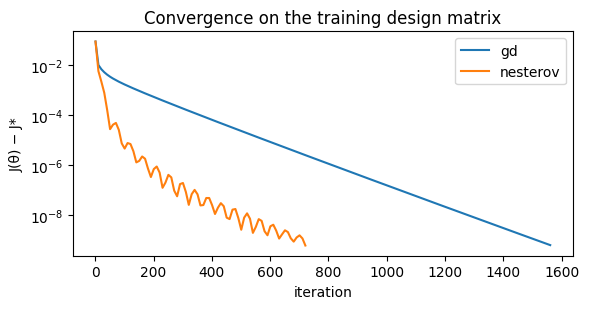

In [14]:
rows = []
for method in ["gd", "nesterov"]:
    t0 = time.time()
    m = LogisticRegressionScratch(lam_chk, method=method, grad_tol=1e-6, max_iter=20000).fit(Zc, yc)
    rows.append({"optimiser": method, "iterations": m.n_iter_, "converged": m.converged_,
                 "seconds": round(time.time() - t0, 2), "final objective": m.objective_})
opt_table = pd.DataFrame(rows)
display(opt_table)

fig, ax = plt.subplots(figsize=(6, 3.2))
for method in ["gd", "nesterov"]:
    m = LogisticRegressionScratch(lam_chk, method=method, grad_tol=1e-6, max_iter=20000).fit(Zc, yc)
    k, h = zip(*m.history_)
    ax.semilogy(k, np.array(h) - ours.objective_ + 1e-12, label=method)
ax.set_xlabel("iteration"); ax.set_ylabel("J(θ) − J*"); ax.set_title("Convergence on the training design matrix")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Evaluation tools and their validation

### 7.1 Metrics
* **Log loss** (primary) and **Brier score** — proper scoring rules.
* **Calibration-in-the-large (CITL):** $\operatorname{logit}P(Y=1)=\alpha+\operatorname{offset}(\operatorname{logit}\hat p)$; ideal $\alpha=0$; $\alpha>0$ means predictions too low on average.
* **Calibration slope (Cox):** $\operatorname{logit}P(Y=1)=a+\beta\operatorname{logit}\hat p$; ideal $\beta=1$; $\beta<1$ means predictions too extreme. Only β is interpreted from this fit.
* **ROC-AUC:** ranking only; invariant to strictly increasing transformations of $\hat p$.
* **Reliability table:** equal-frequency bins.

In [15]:
from sklearn.metrics import roc_auc_score

def _clip(p):
    e = CONFIG["prob_eps"]
    return np.clip(np.asarray(p, float), e, 1 - e)

def logit(p):
    p = _clip(p)
    return np.log(p / (1 - p))

def shot_log_loss(y, p):
    p = _clip(p); y = np.asarray(y, float)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

def shot_brier(y, p):
    return (np.asarray(p, float) - np.asarray(y, float)) ** 2

def citl(y, p, iters=50):
    """Calibration-in-the-large: intercept with logit(p) as a fixed offset (1-D Newton)."""
    y, off, a = np.asarray(y, float), logit(p), 0.0
    for _ in range(iters):
        q = sigmoid(a + off)
        step = np.sum(y - q) / np.sum(q * (1 - q))
        a += step
        if abs(step) < 1e-12:
            break
    return a

def calibration_slope(y, p, iters=100):
    """Cox recalibration slope beta from logit P(Y=1) = a + beta * logit(p) (2-D Newton)."""
    y = np.asarray(y, float); Xc = np.column_stack([np.ones(len(y)), logit(p)]); t = np.array([0.0, 1.0])
    for _ in range(iters):
        q = sigmoid(Xc @ t)
        H = Xc.T @ (Xc * (q * (1 - q))[:, None])
        step = np.linalg.solve(H, Xc.T @ (y - q))
        t += step
        if np.max(np.abs(step)) < 1e-12:
            break
    return t[1]

def reliability_table(y, p, bins=None):
    bins = bins or CONFIG["calibration_bins"]
    df = pd.DataFrame({"y": np.asarray(y, float), "p": np.asarray(p, float)})
    df["bin"] = pd.qcut(df.p.rank(method="first"), bins, labels=False)
    return df.groupby("bin").agg(n=("y", "size"), mean_predicted=("p", "mean"), observed_rate=("y", "mean"))

def summary_metrics(y, p):
    y = np.asarray(y, float)
    return {"log_loss": shot_log_loss(y, p).mean(), "brier": shot_brier(y, p).mean(),
            "citl": citl(y, p), "cal_slope": calibration_slope(y, p), "auc": roc_auc_score(y, p)}

### 7.2 Match-level paired bootstrap and match-grouped cross-validation
Shots from the same match are not independent, so the resampling unit is the match. For a paired comparison, each resample draws matches with replacement and recomputes the mean per-shot loss difference $\bar\ell_A-\bar\ell_B$ over all shots in the drawn matches.

In [16]:
def paired_bootstrap(loss_a, loss_b, groups, B=None, seed=None, ci=None):
    B = B or CONFIG["bootstrap"]["B"]; ci = ci or CONFIG["bootstrap"]["ci"]
    rng = np.random.default_rng(CONFIG["seed"] if seed is None else seed)
    diff = np.asarray(loss_a, float) - np.asarray(loss_b, float)
    g = pd.Series(diff).groupby(np.asarray(groups))
    s, n = g.sum().to_numpy(), g.size().to_numpy()
    idx = rng.integers(0, len(s), size=(B, len(s)))
    boot = s[idx].sum(1) / n[idx].sum(1)
    lo, hi = np.quantile(boot, [(1 - ci) / 2, 1 - (1 - ci) / 2])
    return {"mean_diff": diff.mean(), "ci_low": lo, "ci_high": hi, "n_groups": len(s), "n_shots": len(diff)}

def grouped_folds(groups, k=None, seed=None):
    """Deterministic match-grouped K-fold split: returns a fold index per row."""
    k = k or CONFIG["cv_folds"]
    rng = np.random.default_rng(CONFIG["seed"] if seed is None else seed)
    uniq = np.array(sorted(pd.unique(np.asarray(groups))))
    rng.shuffle(uniq)
    fold_of = {g: i % k for i, g in enumerate(uniq)}
    return np.array([fold_of[g] for g in np.asarray(groups)])

### 7.3 Validation of the evaluation tools on simulated data
Outcomes are simulated from known probabilities, so the correct behaviour of each tool is known in advance.

In [17]:
tool_checks = []
def trecord(name, expected, observed, passed):
    tool_checks.append({"check": name, "expected behaviour": expected, "observed": observed, "pass": bool(passed)})

rs = np.random.default_rng(7)
Nsim = 200_000
p_true = sigmoid(rs.normal(-2.2, 1.1, Nsim))            # realistic xG-like spread (mean ≈ 0.13)
y_sim = (rs.random(Nsim) < p_true).astype(float)

a0, b0 = citl(y_sim, p_true), calibration_slope(y_sim, p_true)
trecord("T1 Perfect calibration", "CITL ≈ 0, slope ≈ 1 (|dev| < 0.03)", f"CITL={a0:.3f}, slope={b0:.3f}",
        abs(a0) < 0.03 and abs(b0 - 1) < 0.03)

p_high = sigmoid(logit(p_true) + 0.5)
a1 = citl(y_sim, p_high)
trecord("T2 Predictions shifted up (c = +0.5)", "CITL ≈ −0.5 (negative)", f"CITL={a1:.3f}", abs(a1 + 0.5) < 0.03)

p_sharp = sigmoid(1.5 * logit(p_true))
b2 = calibration_slope(y_sim, p_sharp)
auc_eq = abs(roc_auc_score(y_sim, p_true) - roc_auc_score(y_sim, p_sharp))
ll_worse = shot_log_loss(y_sim, p_sharp).mean() > shot_log_loss(y_sim, p_true).mean()
trecord("T3 Over-extreme predictions (k = 1.5)", "slope ≈ 1/1.5; AUC unchanged; log loss worse",
        f"slope={b2:.3f}, |ΔAUC|={auc_eq:.1e}, LL worse={ll_worse}",
        abs(b2 - 1 / 1.5) < 0.03 and auc_eq < 1e-12 and ll_worse)

grp = rs.integers(0, 130, Nsim)
bz = paired_bootstrap(shot_log_loss(y_sim, p_true), shot_log_loss(y_sim, p_true), grp, B=500)
trecord("T4 Identical predictions", "difference and CI exactly 0", f"[{bz['ci_low']}, {bz['ci_high']}]",
        bz["mean_diff"] == 0 and bz["ci_low"] == 0 and bz["ci_high"] == 0)

bd = shot_brier(y_sim, p_sharp) - shot_brier(y_sim, p_true)
trecord("T5 Per-shot Brier difference range", "within [−1, 1]", f"[{bd.min():.3f}, {bd.max():.3f}]",
        bd.min() >= -1 and bd.max() <= 1)

bb = paired_bootstrap(shot_log_loss(y_sim, p_sharp), shot_log_loss(y_sim, p_true), grp, B=500)
trecord("T6 Bootstrap detects a real degradation", "CI entirely above 0",
        f"[{bb['ci_low']:.4f}, {bb['ci_high']:.4f}]", bb["ci_low"] > 0)

tool_table = pd.DataFrame(tool_checks)
display(tool_table)
assert tool_table["pass"].all(), "An evaluation-tool check failed"

,check,expected behaviour,observed,pass
0,T1 Perfect calibration,"CITL ≈ 0, slope ≈ 1 (|dev| < 0.03)","CITL=0.009, slope=0.998",True
1,T2 Predictions shifted up (c = +0.5),CITL ≈ −0.5 (negative),CITL=-0.491,True
2,T3 Over-extreme predictions (k = 1.5),slope ≈ 1/1.5; AUC unchanged; log loss worse,"slope=0.665, |ΔAUC|=0.0e+00, LL worse=True",True
3,T4 Identical predictions,difference and CI exactly 0,"[0.0, 0.0]",True
4,T5 Per-shot Brier difference range,"within [−1, 1]","[-0.043, 0.150]",True
5,T6 Bootstrap detects a real degradation,CI entirely above 0,"[0.0303, 0.0327]",True


## 8. Development decisions (training pool → φ\* → λ); no test events

Every λ in this section is chosen by match-grouped 5-fold cross-validation **inside the training pool**: the preprocessing (including the rare-category map) is fitted on each training fold only, out-of-fold probabilities are pooled, and the λ with the lowest pooled out-of-fold log loss is chosen (ties within $10^{-4}$ → larger λ). The 2020/21 season is used for exactly two structural choices: the training pool (8.1) and φ\* (8.2).

In [18]:
test_ids = matches.loc[matches.season_id == CONFIG["test_season"], "match_id"]
present = [m for m in test_ids if (CACHE_DIR / "events" / f"{m}.json").exists()]
if present:
    raise RuntimeError(f"{len(present)} test event files already exist in the cache. Start a fresh runtime "
                       "(or clear the cache) before reproducing the development sequence.")
print(f"Protocol check: 0 of {len(test_ids)} test-season event files present before freezing.")

val_mask = (meta_dev.season_id == CONFIG["validation_season"]).to_numpy()
def pool_mask(pool):
    return meta_dev.season_id.isin(CONFIG["pools"][pool]).to_numpy()

def cv_select_lambda(spec, mask):
    """Match-grouped K-fold CV inside `mask`; returns (selected lambda, CV table)."""
    idx = np.where(mask)[0]
    F, y = F_dev.iloc[idx], y_dev.to_numpy()[idx]
    folds = grouped_folds(meta_dev.match_id.to_numpy()[idx])
    rows = []
    for lam in CONFIG["lambda_grid"]:
        oof, conv = np.empty(len(y)), True
        for k in range(CONFIG["cv_folds"]):
            tr, te = np.where(folds != k)[0], np.where(folds == k)[0]
            pre, m = fit_model(spec, F.iloc[tr], y[tr], lam)
            oof[te] = predict(pre, m, F.iloc[te])
            conv &= m.converged_
        rows.append({"lambda": lam, "oof_log_loss": shot_log_loss(y, oof).mean(), "all_converged": conv})
    tab = pd.DataFrame(rows)
    tied = tab[tab.oof_log_loss <= tab.oof_log_loss.min() + CONFIG["lambda_tie_tolerance"]]
    return float(tied["lambda"].max()), tab

def fit_and_validate(spec, pool, lam):
    pm = pool_mask(pool)
    pre, m = fit_model(spec, F_dev[pm], y_dev[pm], lam)
    return pre, m, predict(pre, m, F_dev[val_mask])

y_val = y_dev[val_mask].to_numpy()
g_val = meta_dev.match_id[val_mask].to_numpy()
t_dev = time.time()

Protocol check: 0 of 132 test-season event files present before freezing.


### 8.1 Step 1 — training pool (anchor: untransformed M2)

In [19]:
spec_M2_raw = model_spec("M2", "raw")
step1, val_loss = [], {}
for pool in ["D_full", "D_recent"]:
    lam, tab = cv_select_lambda(spec_M2_raw, pool_mask(pool))
    pre, m, p_val = fit_and_validate(spec_M2_raw, pool, lam)
    val_loss[pool] = shot_log_loss(y_val, p_val)
    step1.append({"pool": pool, "seasons": ", ".join(season_name[s] for s in CONFIG["pools"][pool]),
                  "train shots": int(pool_mask(pool).sum()), "CV-selected λ": lam,
                  "CV OOF log loss": tab.oof_log_loss.min(), "validation log loss": val_loss[pool].mean()})
display(pd.DataFrame(step1))

b1 = paired_bootstrap(val_loss["D_full"], val_loss["D_recent"], g_val)
EXCLUDE_LEGACY = bool(b1["mean_diff"] > 0 and b1["ci_low"] > 0)
POOL = "D_recent" if EXCLUDE_LEGACY else "D_full"
print(f"Δ_legacy = LL_full − LL_recent = {b1['mean_diff']:+.5f}  "
      f"95% match-bootstrap CI [{b1['ci_low']:+.5f}, {b1['ci_high']:+.5f}]  ({b1['n_groups']} matches)")
print(f"Pre-declared rule → {'exclude' if EXCLUDE_LEGACY else 'keep'} 2018/19; training pool = {POOL}")

,pool,seasons,train shots,CV-selected λ,CV OOF log loss,validation log loss
0,D_full,"2018/19, 2019/20",4993,0.001,0.296388,0.303746
1,D_recent,2019/20,2201,0.003,0.299681,0.308366


Δ_legacy = LL_full − LL_recent = -0.00462  95% match-bootstrap CI [-0.00728, -0.00202]  (131 matches)
Pre-declared rule → keep 2018/19; training pool = D_full


This result measures the **net** effect of including 2018/19 on predictions for a later season. It changes several things at once (data version and coordinate precision, sample size, recency, season mix), so it is not attributed to data fidelity alone. The pool decision is not re-opened later.

### 8.2 Step 2 — common geometric mapping φ\* (decided with M1)

In [20]:
step2 = []
for phi in CONFIG["phi_candidates"]:
    spec = model_spec("M1", phi)
    lam, tab = cv_select_lambda(spec, pool_mask(POOL))
    pre, m, p_val = fit_and_validate(spec, POOL, lam)
    step2.append({"phi": phi, "CV-selected λ": lam, "CV OOF log loss": tab.oof_log_loss.min(),
                  "validation log loss": shot_log_loss(y_val, p_val).mean()})
step2 = pd.DataFrame(step2)
best = step2["validation log loss"].min()
PHI_STAR = step2.loc[step2["validation log loss"] <= best + CONFIG["phi_tie_tolerance"], "phi"].iloc[0]
LAMBDA_M1 = float(step2.set_index("phi").loc[PHI_STAR, "CV-selected λ"])
display(step2)
print(f"φ* = {PHI_STAR} (lowest validation log loss; ties within {CONFIG['phi_tie_tolerance']} → simpler). "
      f"M1* keeps its CV-selected λ = {LAMBDA_M1}")

,phi,CV-selected λ,CV OOF log loss,validation log loss
0,raw,0.0030,0.309237,0.318773
1,log_distance,0.0030,0.309118,0.317661
2,distance_quadratic,0.0003,0.308798,0.317753
3,log_distance_x_angle,0.0030,0.309237,0.317873


φ* = log_distance (lowest validation log loss; ties within 0.0001 → simpler). M1* keeps its CV-selected λ = 0.003


### 8.3 Step 3 — λ for M2\* (same CV protocol, inside the chosen pool)

In [21]:
LAMBDA_M2, tab_m2 = cv_select_lambda(model_spec("M2", PHI_STAR), pool_mask(POOL))
display(tab_m2)
print(f"M2* λ = {LAMBDA_M2}.  Development decisions took {time.time() - t_dev:.0f}s.")

,lambda,oof_log_loss,all_converged
0,0.00001,0.296987,True
1,0.00010,0.296826,True
2,0.00030,0.296586,True
3,0.00100,0.296333,True
4,0.00300,0.296739,True
5,0.01000,0.298989,True
6,0.03000,0.303316,True
7,0.10000,0.309552,True


M2* λ = 0.001.  Development decisions took 17s.


**Fold-balance audit (diagnostic only).** The match-grouped folds are not stratified. The table shows each fold of the chosen training pool. In the archived run no fold is obviously anomalous in match count, shot count or base rate, reducing concern that λ selection was dominated by a severely imbalanced fold. It does not feed any decision.

In [22]:
pm = pool_mask(POOL)
fold_id = grouped_folds(meta_dev.match_id.to_numpy()[pm])
fold_audit = (pd.DataFrame({"fold": fold_id, "match_id": meta_dev.match_id.to_numpy()[pm], "goal": y_dev.to_numpy()[pm]})
                .groupby("fold").agg(matches=("match_id", "nunique"), shots=("goal", "size"),
                                     goals=("goal", "sum"), goal_rate=("goal", "mean")))
display(fold_audit.round(4))

,matches,shots,goals,goal_rate
fold,,,,
0,39,1012,101,0.0998
1,39,999,96,0.0961
2,39,1018,117,0.1149
3,39,976,101,0.1035
4,38,988,114,0.1154


Validation-season numbers above are **post-selection diagnostics**: 2020/21 was used for two choices, so its scores are not an unbiased estimate of future performance. Research conclusions come only from the 2023/24 test season (Section 10).

## 9. Frozen record and refit

The fresh run must reproduce the development decisions recorded when this notebook was archived; otherwise the notebook stops before any test data is downloaded.

The fingerprint printed below is a hash of the serialised `CONFIG` and the frozen decision record: it confirms that these are unchanged. It does not identify the code; the complete code version is identified separately by the Git commit linked in the Journal.

In [23]:
# Recorded in the archived development run (after revision R1). A fresh run must reproduce them exactly.
EXPECTED_DEVELOPMENT_DECISIONS = {"training_pool": "D_full", "phi_star": "log_distance",
                                  "lambda_M1_star": 0.003, "lambda_M2_star": 0.001}

FROZEN_RECORD = {
    "training_pool": POOL, "phi_star": PHI_STAR, "lambda_M1_star": LAMBDA_M1, "lambda_M2_star": LAMBDA_M2,
    "training_seasons": CONFIG["pools"][POOL],
    "refit_seasons": CONFIG["pools"][POOL] + [CONFIG["validation_season"]],
    "category_map_fitted_on": "selected training pool (frozen; reused at refit and test)",
    "standardisation_fitted_on": "refit data (training pool + 2020/21)",
    "M1_star": model_spec("M1", PHI_STAR), "M2_star": model_spec("M2", PHI_STAR),
    "M2_star_class_weighted": {"spec": "identical to M2*", "lambda": LAMBDA_M2, "weights": CONFIG["class_weight"]["rule"]},
    "M0": "constant = goal rate of the refit data",
    "primary": "mean per-shot log loss difference M2* − M1* on 2023/24, match-level paired bootstrap 95% CI",
    "secondary": ["Brier (and M2*−M1* difference)", "CITL (offset)", "Cox calibration slope",
                  "reliability table", "ROC-AUC", "subgroups", "base-rate drift",
                  "class-weighting case", "team-match non-penalty xG", "StatsBomb xG reference"],
    "development_data_digest": data_digest(dev_manifest),
}
observed = {k: FROZEN_RECORD[k] for k in EXPECTED_DEVELOPMENT_DECISIONS}
if observed != EXPECTED_DEVELOPMENT_DECISIONS:
    raise RuntimeError(f"Development decisions not reproduced: expected {EXPECTED_DEVELOPMENT_DECISIONS}, "
                       f"observed {observed}. Test data will not be loaded.")
FROZEN_FINGERPRINT = config_fingerprint({"config": CONFIG, "frozen_record": FROZEN_RECORD})
print("Development decisions reproduced:", observed)

Development decisions reproduced: {'training_pool': 'D_full', 'phi_star': 'log_distance', 'lambda_M1_star': 0.003, 'lambda_M2_star': 0.001}


In [24]:
refit_mask = pool_mask(POOL) | val_mask
F_refit, y_refit = F_dev[refit_mask], y_dev[refit_mask].to_numpy()

def fit_frozen(spec, lam, weights=None):
    pre = Preprocessor(spec).fit(F_dev[pool_mask(POOL)], y_dev[pool_mask(POOL)])   # category map: training pool
    pre.refit_scaling(F_refit)                              # scaling: refit data
    opt = CONFIG["optimizer"]
    m = LogisticRegressionScratch(lam, opt["method"], opt["grad_tol"], opt["max_iter"])
    m.fit(pre.transform(F_refit), y_refit, sample_weight=weights)
    if not m.converged_:
        raise RuntimeError("Final refit did not converge")
    return pre, m

n1, n0 = y_refit.sum(), (1 - y_refit).sum()
cw = np.where(y_refit == 1, len(y_refit) / (2 * n1), len(y_refit) / (2 * n0))   # mean weight = 1

FINAL = {
    "M1*": fit_frozen(model_spec("M1", PHI_STAR), LAMBDA_M1),
    "M2*": fit_frozen(model_spec("M2", PHI_STAR), LAMBDA_M2),
    "M2*_cw": fit_frozen(model_spec("M2", PHI_STAR), LAMBDA_M2, weights=cw),
}
P0 = float(y_refit.mean())
FROZEN = True

display(pd.DataFrame([
    {"item": "configuration + frozen-record fingerprint", "value": FROZEN_FINGERPRINT},
    {"item": "data commit", "value": CONFIG["statsbomb_commit"][:12]},
    {"item": "refit shots / goals", "value": f"{len(y_refit)} / {int(n1)}"},
    {"item": "M0 constant probability", "value": f"{P0:.4f}"},
    {"item": "class weights (goal, no goal)", "value": f"{len(y_refit)/(2*n1):.3f}, {len(y_refit)/(2*n0):.3f} (mean {cw.mean():.3f})"},
    {"item": "RARE_OR_UNSEEN bucket active (else merged into reference)",
     "value": str(FINAL["M2*"][0].bucket_active_)},
    {"item": "rare categories merged", "value": str({k: v for k, v in FINAL["M2*"][0].rare_levels_.items() if v})},
]).set_index("item"))

coef = pd.DataFrame({
    "M2* coefficient": pd.Series(FINAL["M2*"][1].coef_, index=FINAL["M2*"][0].columns_),
    "M1* coefficient": pd.Series(FINAL["M1*"][1].coef_, index=FINAL["M1*"][0].columns_),
})
coef.loc["(intercept)"] = [FINAL["M2*"][1].intercept_, FINAL["M1*"][1].intercept_]
display(coef.round(3))
print("Continuous geometric inputs are standardised; categorical coefficients are relative to the "
      "reference level:", {c: FINAL["M2*"][0].reference_[c] for c in CONFIG["context_categorical"]})

,value
item,
configuration + frozen-record fingerprint,48ef8e004ab3
data commit,4b73468fc5b0
refit shots / goals,8204 / 897
M0 constant probability,0.1093
"class weights (goal, no goal)","4.573, 0.561 (mean 1.000)"
RARE_OR_UNSEEN bucket active (else merged into reference),"{'body_part': False, 'shot_type': False, 'tech..."
rare categories merged,"{'body_part': ['Other'], 'shot_type': ['Corner..."


,M2* coefficient,M1* coefficient
aerial_won,-0.455,NaN
angle,0.173,0.170
assist_type=Cross,-0.022,NaN
assist_type=Ground Pass,0.150,NaN
assist_type=High Pass,0.052,NaN
assist_type=Low Pass,0.174,NaN
assist_type=Set-piece pass,-0.296,NaN
assist_type=Through ball,0.748,NaN
body_part=Head,-0.445,NaN
first_time,0.138,NaN


Continuous geometric inputs are standardised; categorical coefficients are relative to the reference level: {'body_part': 'Foot', 'shot_type': 'Open Play', 'technique': 'Normal', 'play_pattern': 'Regular Play', 'assist_type': 'No recorded key pass'}


**Training-support diagnostic for M2\* (diagnostic only).** For every level that has its own coefficient, and for every boolean feature, the table gives its support in the training pool (the data that defined the category map) and in the refit data, together with the final coefficient. Boolean features are not covered by the category-support rule, so they are audited here as well. The distribution of fitted probabilities checks for globally extreme fitted predictions in the refit data; together with the support and coefficient table, it provides evidence against remaining near-separation. The single highest-probability shot is listed by its model inputs only.

In [25]:
pre2, m2 = FINAL["M2*"]
F_pool, y_pool = F_dev[pool_mask(POOL)], y_dev[pool_mask(POOL)]
rows = []
for c in CONFIG["context_categorical"]:
    for lvl in pre2.levels_[c]:
        members = pre2.rare_levels_[c] if lvl == CONFIG["rare_bucket"] else [lvl]
        for nm, Fx, yx in [("pool", F_pool, y_pool), ("refit", F_refit, pd.Series(y_refit, index=F_refit.index))]:
            msk = Fx[c].isin(members)
            if nm == "pool":
                row = {"feature level": f"{c}={lvl}", "pool shots": int(msk.sum()), "pool goals": int(yx[msk].sum()),
                       "pool non-goals": int(msk.sum() - yx[msk].sum())}
            else:
                row.update({"refit shots": int(msk.sum()), "refit goals": int(yx[msk].sum()),
                            "refit non-goals": int(msk.sum() - yx[msk].sum())})
        row["coefficient"] = float(m2.coef_[pre2.columns_.index(f"{c}={lvl}")])
        rows.append(row)
for b in CONFIG["context_boolean"]:
    mp, mr = F_pool[b] == 1, F_refit[b] == 1
    rows.append({"feature level": b, "pool shots": int(mp.sum()), "pool goals": int(y_pool[mp].sum()),
                 "pool non-goals": int(mp.sum() - y_pool[mp].sum()), "refit shots": int(mr.sum()),
                 "refit goals": int(y_refit[mr.to_numpy()].sum()),
                 "refit non-goals": int(mr.sum() - y_refit[mr.to_numpy()].sum()),
                 "coefficient": float(m2.coef_[pre2.columns_.index(b)])})
display(pd.DataFrame(rows).set_index("feature level").round(3))

p_fit = predict(pre2, m2, F_refit)
display(pd.DataFrame({"fitted probability (refit data)": {
    "min": p_fit.min(), "median": np.median(p_fit), "99th percentile": np.quantile(p_fit, 0.99), "max": p_fit.max()}}).round(4))
top = F_refit.iloc[[int(np.argmax(p_fit))]].drop(columns=["inside_box"]).T.rename(columns=lambda _: "highest fitted p").rename_axis(None, axis=1)
display(top)

,pool shots,pool goals,pool non-goals,refit shots,refit goals,refit non-goals,coefficient
feature level,,,,,,,
body_part=Head,738,90,648,1270,168,1102,-0.445
shot_type=Free Kick,166,14,152,260,26,234,0.759
technique=Half Volley,451,50,401,877,105,772,-0.167
technique=Volley,282,35,247,479,68,411,-0.320
technique=Lob,44,19,25,64,31,33,1.429
technique=RARE_OR_UNSEEN,43,5,38,75,10,65,-0.286
play_pattern=From Throw In,1047,86,961,1710,159,1551,-0.192
play_pattern=From Corner,833,80,753,1412,142,1270,-0.416
play_pattern=From Free Kick,780,86,694,1268,140,1128,-0.012


,fitted probability (refit data)
min,0.0073
median,0.0726
99th percentile,0.6076
max,0.9435


,highest fitted p
distance,1.0
angle,2.651635
body_part,Head
shot_type,Open Play
technique,Normal
play_pattern,Regular Play
assist_type,No recorded key pass
first_time,0
under_pressure,0
one_on_one,1


**Frozen.** Nothing above this line is changed after this point. Section 10 is the first access to the test-season events by this corrected notebook and runtime, and computes every pre-declared quantity in a single call. A prior invalid evaluation by a separate implementation is disclosed in §1.4 and is not reported as evidence.

## 10. Final test: 2023/24 (corrected frozen pipeline, evaluated once)

### 10.0 Test loader, dataset-level checks and the evaluation function (definitions only)

In [ ]:
TEST_LOCK = CACHE_DIR / "TEST_EVALUATED.lock"
EXPECTED_RAW_COLUMNS = set(X_dev_raw.columns)

def build_test_tables():
    """Access to the test-season events by this corrected notebook; allowed once, after freezing."""
    if not FROZEN or config_fingerprint({"config": CONFIG, "frozen_record": FROZEN_RECORD}) != FROZEN_FINGERPRINT:
        raise RuntimeError("Protocol guard: the protocol is not frozen (or the frozen record changed).")
    if TEST_LOCK.exists():
        raise RuntimeError("Protocol guard: the test season has already been evaluated in this environment.")
    rows = matches[matches.season_id == CONFIG["test_season"]]
    manifest = download_events(rows.match_id.tolist())
    X, y, ref, outc = build_tables(rows)
    return X, y, ref, outc, manifest

def dataset_level_checks(X, outcomes, season_id):
    problems = []
    if not X.index.is_unique:
        problems.append("duplicate shot ids")
    if set(X.season_id.unique()) != {season_id}:
        problems.append("unexpected season ids")
    if set(X.columns) != EXPECTED_RAW_COLUMNS:
        problems.append(f"schema change: {set(X.columns) ^ EXPECTED_RAW_COLUMNS}")
    if not (pd.api.types.is_numeric_dtype(X.x) and pd.api.types.is_numeric_dtype(X.y)):
        problems.append("location columns are not numeric")
    unknown = set(outcomes.unique()) - set(CONFIG["known_outcomes"])
    if unknown:
        problems.append(f"unrecognised outcome codes {unknown}")
    if problems:
        raise RuntimeError("Dataset-level failure — test computation stopped, frozen pipeline unchanged: "
                           + "; ".join(problems))

def group_metrics(y, preds, mask):
    out = {"shots": int(mask.sum()), "goals": int(y[mask].sum())}
    for name, p in preds.items():
        out[f"LL {name}"] = shot_log_loss(y[mask], p[mask]).mean()
        out[f"mean p {name}"] = p[mask].mean()
    out["observed rate"] = y[mask].mean()
    return out

def run_final_evaluation(X_raw, y_raw, ref_raw, outcomes, season_id):
    dataset_level_checks(X_raw, outcomes, season_id)
    X, y_s, flow = apply_population(X_raw, y_raw)
    F = build_features(X)
    y = y_s.to_numpy().astype(float)
    groups = X.match_id.to_numpy()
    _, unseen = FINAL["M2*"][0].transform(F, report_unseen=True)
    preds = {"M0": np.full(len(y), P0)}
    preds.update({k: predict(pre, m, F) for k, (pre, m) in FINAL.items()})
    R = {"flow": flow, "unseen_categories": unseen, "n_shots": len(y), "n_goals": int(y.sum())}

    ll = {k: shot_log_loss(y, p) for k, p in preds.items()}
    br = {k: shot_brier(y, p) for k, p in preds.items()}
    R["primary"] = paired_bootstrap(ll["M2*"], ll["M1*"], groups)
    R["M1_vs_M0"] = paired_bootstrap(ll["M1*"], ll["M0"], groups)
    R["brier_diff"] = paired_bootstrap(br["M2*"], br["M1*"], groups)

    rows = []
    for k, p in preds.items():
        row = {"model": k, "log loss": ll[k].mean(), "Brier": br[k].mean(), "mean p": p.mean()}
        if k != "M0":
            row.update({"CITL": citl(y, p), "cal. slope": calibration_slope(y, p), "AUC": roc_auc_score(y, p)})
        rows.append(row)
    R["secondary"] = pd.DataFrame(rows).set_index("model")
    R["reliability"] = {k: reliability_table(y, preds[k]) for k in ["M1*", "M2*"]}

    hp_cut = np.quantile(preds["M2*"], 0.9)                        # label-free definition
    masks = {"header": (F.body_part == "Head").to_numpy(), "non-header": (F.body_part != "Head").to_numpy(),
             "inside box": (F.inside_box == 1).to_numpy(), "outside box": (F.inside_box == 0).to_numpy(),
             "top 10% M2* predictions": preds["M2*"] >= hp_cut}
    sub = []
    for name, msk in masks.items():
        row = {"group": name, **group_metrics(y, {k: preds[k] for k in ["M1*", "M2*"]}, msk)}
        if row["goals"] >= CONFIG["min_goals_for_inference"]:
            b = paired_bootstrap(ll["M2*"][msk], ll["M1*"][msk], groups[msk])
            row.update({"Δ LL (M2*−M1*)": b["mean_diff"], "CI low": b["ci_low"], "CI high": b["ci_high"]})
        sub.append(row)
    R["subgroups"] = pd.DataFrame(sub).set_index("group")
    R["high_prob_cut"] = hp_cut

    R["drift"] = pd.DataFrame({"goal rate": [y_refit.mean(), y.mean()],
                               "shots": [len(y_refit), len(y)]}, index=["refit data", "test season"])

    thr = CONFIG["classification_threshold"]
    cwrows = []
    for k in ["M2*", "M2*_cw"]:
        yhat = preds[k] >= thr
        tp = int((yhat & (y == 1)).sum())
        cwrows.append({"model": k, "recall@0.5": tp / max(int(y.sum()), 1),
                       "precision@0.5": tp / max(int(yhat.sum()), 1), "unweighted log loss": ll[k].mean(),
                       "Brier": br[k].mean(), "mean p": preds[k].mean(), "observed rate": y.mean(),
                       "CITL": citl(y, preds[k]), "cal. slope": calibration_slope(y, preds[k]),
                       "AUC": roc_auc_score(y, preds[k])})
    R["class_weighting"] = pd.DataFrame(cwrows).set_index("model")

    tm = pd.DataFrame({"match_id": X.match_id.to_numpy(), "team_id": X.team_id.to_numpy(), "goals": y,
                       "M1*": preds["M1*"], "M2*": preds["M2*"]})
    tm = tm.groupby(["match_id", "team_id"]).sum()
    R["team_match"] = pd.DataFrame({k: {"mean xG per team-match": tm[k].mean(),
                                        "mean goals per team-match": tm.goals.mean(),
                                        "MAE vs goals": (tm[k] - tm.goals).abs().mean(),
                                        "correlation with goals": np.corrcoef(tm[k], tm.goals)[0, 1]}
                                    for k in ["M1*", "M2*"]}).T
    R["team_match_n"] = len(tm)

    ref = ref_raw.reindex(X.index).to_numpy(float)
    ok = ~np.isnan(ref)
    R["statsbomb"] = pd.DataFrame([{"model": k, "log loss": shot_log_loss(y[ok], p[ok]).mean(),
                                    "Brier": shot_brier(y[ok], p[ok]).mean(), "AUC": roc_auc_score(y[ok], p[ok]),
                                    "CITL": citl(y[ok], p[ok]), "cal. slope": calibration_slope(y[ok], p[ok])}
                                   for k, p in [("M1*", preds["M1*"]), ("M2*", preds["M2*"]),
                                                ("StatsBomb xG", ref)]]).set_index("model")
    R["statsbomb_coverage"] = float(ok.mean())
    R["_y"], R["_preds"], R["_ll"], R["_br"], R["_groups"] = y, preds, ll, br, groups
    return R

### 10.1 Load the test season and evaluate the frozen pipeline once

In [ ]:
X_test_raw, y_test_raw, ref_test_raw, outcome_test_raw, test_manifest = build_test_tables()
TEST = run_final_evaluation(X_test_raw, y_test_raw, ref_test_raw, outcome_test_raw, CONFIG["test_season"])
TEST_LOCK.write_text(json.dumps({"fingerprint": FROZEN_FINGERPRINT, "time": time.ctime()}))
print(f"Frozen pipeline evaluated once. Fingerprint {FROZEN_FINGERPRINT}; test data digest {data_digest(test_manifest)}; "
      f"{TEST['n_shots']} evaluable non-penalty shots, {TEST['n_goals']} goals.")
display(TEST["flow"].set_index("step"))
print("Unseen categories mapped to RARE_OR_UNSEEN:", TEST["unseen_categories"])

### 10.2 Primary result

In [ ]:
pr = TEST["primary"]
display(pd.DataFrame([
    {"comparison": "M2* − M1* (primary)", **{k: pr[k] for k in ["mean_diff", "ci_low", "ci_high", "n_groups", "n_shots"]}},
    {"comparison": "M1* − M0 (sanity)", **{k: TEST["M1_vs_M0"][k] for k in ["mean_diff", "ci_low", "ci_high", "n_groups", "n_shots"]}},
]).set_index("comparison"))
verdict = ("context improves out-of-season log loss" if pr["ci_high"] < 0 else
           "context worsens out-of-season log loss" if pr["ci_low"] > 0 else
           "no clear difference at the 95% level")
print(f"Answer to the research question: {verdict} "
      f"(Δ = {pr['mean_diff']:+.5f}, 95% CI [{pr['ci_low']:+.5f}, {pr['ci_high']:+.5f}]).")

### 10.3 Where does the difference come from? Calibration, ranking and a second proper score
Proper scores reward both calibration and discrimination. CITL and the calibration slope diagnose calibration; AUC diagnoses ranking only. They help interpret the primary result but are not an exact decomposition of it.

In [ ]:
display(TEST["secondary"].round(4))
bd = TEST["brier_diff"]
print(f"Brier difference M2* − M1*: {bd['mean_diff']:+.5f}, 95% CI [{bd['ci_low']:+.5f}, {bd['ci_high']:+.5f}]")

fig, ax = plt.subplots(figsize=(4.8, 4.5))
for k, r in TEST["reliability"].items():
    ax.plot(r.mean_predicted, r.observed_rate, "o-", label=k)
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim], [0, lim], "k--", lw=1, label="perfect calibration")
ax.set_xlabel("mean predicted probability (equal-frequency bins)"); ax.set_ylabel("observed goal rate")
ax.set_title("Reliability, 2023/24 test season"); ax.legend(); plt.tight_layout(); plt.show()

### 10.4 Pre-declared failure analysis: subgroups and the high-probability region
Groups with fewer than `min_goals_for_inference` goals are described only.

In [ ]:
print(f"High-probability group: M2* prediction ≥ {TEST['high_prob_cut']:.3f} (top 10%, label-free).")
display(TEST["subgroups"].round(4))

### 10.5 Base-rate drift between the refit data and the test season
A CITL away from 0 together with a slope near 1 is *consistent with* a shift in the overall scoring rate while the relative structure still holds. A mitigation (re-estimating only the intercept on recent data) is proposed for future deployment; it is **not** applied to this test season, which would contaminate the evaluation.

In [ ]:
display(TEST["drift"].round(4))
display(TEST["secondary"].loc[["M1*", "M2*"], ["CITL", "cal. slope"]].round(4))

### 10.6 Loss vs task objective: class weighting
The class-weighted model is identical to M2\* except for mean-one class weights in the training loss. Weighting optimises a *different* objective; it can raise threshold-based recall while worsening the unweighted log loss and calibration that an xG model needs.

In [ ]:
display(TEST["class_weighting"].round(4))

### 10.7 Downstream use: team-match non-penalty xG
Actual goals are only those produced by the same evaluable non-penalty shots (penalties and own goals excluded), so predicted and actual totals share one population.

In [ ]:
print(f"{TEST['team_match_n']} team-matches")
display(TEST["team_match"].round(4))

### 10.8 External reference: StatsBomb xG (not a like-for-like comparison)
StatsBomb's model, inputs and training data are not fully public and may overlap with these competitions. It is an industry reference, not ground truth.

In [ ]:
print(f"StatsBomb xG coverage of evaluable test shots: {TEST['statsbomb_coverage']:.1%}")
display(TEST["statsbomb"].round(4))

## 11. Deployment demonstration (full frozen pipeline)
A raw shot record → input validation → feature construction → frozen preprocessing → M2\* → probability.

In [ ]:
REQUIRED_FIELDS = {"x", "y", "body_part_raw", "shot_type", "technique", "play_pattern", "assist_type",
                   *CONFIG["context_boolean"]}

def predict_shot(record):
    missing = REQUIRED_FIELDS - set(record)
    if missing:
        raise ValueError(f"Missing fields: {missing}")
    if record["shot_type"] in CONFIG["exclude_shot_types"]:
        raise ValueError("Penalties are outside the model's scope.")
    if not (CONFIG["valid_x"][0] <= record["x"] <= CONFIG["valid_x"][1]
            and CONFIG["valid_y"][0] <= record["y"] <= CONFIG["valid_y"][1]):
        raise ValueError("Location outside the 120 x 80 pitch.")
    X = pd.DataFrame([record])
    for c in CONFIG["context_boolean"]:
        X[c] = bool(X[c].iloc[0])
    pre, m = FINAL["M2*"]
    p = float(predict(pre, m, build_features(X))[0])
    assert 0.0 < p < 1.0
    return p

example = {"x": 108.0, "y": 36.0, "body_part_raw": "Right Foot", "shot_type": "Open Play",
           "technique": "Normal", "play_pattern": "Regular Play", "assist_type": "No recorded key pass",
           "first_time": True, "under_pressure": False, "one_on_one": False, "open_goal": False,
           "aerial_won": False}
print(f"Estimated non-penalty goal probability: {predict_shot(example):.3f} "
      "(a probability estimate, not a goal/no-goal decision)")

## 12. Conclusion
The Journal contains the full discussion (limitations, monitoring and future work). Here only the research question is answered.

In [ ]:
print(f"On {TEST['n_shots']} non-penalty shots from the 2023/24 FA WSL season (evaluated once by this frozen pipeline; see §1.4), "
      f"M2* − M1* log loss = {pr['mean_diff']:+.5f} (95% match-bootstrap CI {pr['ci_low']:+.5f} to {pr['ci_high']:+.5f}): "
      f"{verdict}.")
print("Limitations: one test season; 2019/20 curtailed; older 2018/19 data recorded differently; "
      "event data describe defensive pressure only coarsely; a single binary outcome cannot reveal a shot's true probability.")

## Appendix A. Hoeffding bound for the Brier score (illustrative)
For a model fixed before seeing the test data and i.i.d. losses bounded in $[a,b]$, Hoeffding gives, with probability $\ge 1-\delta$, $|\hat R - R|\le (b-a)\sqrt{\ln(2/\delta)/(2n)}$. The per-shot Brier loss lies in $[0,1]$, the paired Brier difference in $[-1,1]$ (width 2). Log loss is unbounded, so this version does not apply to it. Shots within a match are not independent, so the bound is an idealisation; the match bootstrap remains the primary uncertainty method.

In [ ]:
n = TEST["n_shots"]; delta = 0.05
eps1 = math.sqrt(math.log(2 / delta) / (2 * n))
display(pd.DataFrame([
    {"quantity": "Brier(M2*)", "Hoeffding half-width": eps1, "bootstrap half-width": np.nan},
    {"quantity": "Brier(M2*) − Brier(M1*)", "Hoeffding half-width": 2 * eps1,
     "bootstrap half-width": (TEST["brier_diff"]["ci_high"] - TEST["brier_diff"]["ci_low"]) / 2},
]).set_index("quantity"))

## Appendix B. Reproducibility record

In [ ]:
display(pd.DataFrame({"value": {
    "notebook version": "GitHub commit linked in the Journal",
    "data commit": CONFIG["statsbomb_commit"],
    "fingerprint (config + frozen record)": FROZEN_FINGERPRINT,
    "development data digest": data_digest(dev_manifest),
    "test data digest": data_digest(test_manifest),
    "numpy / pandas / scikit-learn": f"{np.__version__} / {pd.__version__} / {sklearn.__version__}",
    "seed": CONFIG["seed"],
}}))